In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

1.1 Выберите из таблицы data данные только по АЗС с долей «аномально быстрых» заездов меньше 50%. 

Сравните число «хороших» АЗС с количеством всех АЗС. Решите задачу в несколько шагов:

1) Выберите id АЗС, чья доля «аномально быстрых» заездов меньше 50%. Сохраните их id в переменной good_ids. Получите id «хороших» АЗС, применив query() к столбцу из таблицы too_fast_stat. Сначала напечатайте её, чтобы вспомнить название нужного столбца.

In [4]:
data = pd.read_csv("./visits.csv", sep="\t")
data.head()

,date_time,id,time_spent,name
0,20180406T165358,76144fb2,98.0,Василёк
1,20180404T173913,76144fb2,15.0,Василёк
2,20180403T172824,76144fb2,220.0,Василёк
3,20180407T070441,76144fb2,19.0,Василёк
4,20180404T132049,76144fb2,14.0,Василёк


In [5]:
data['date_time'] = pd.to_datetime(data['date_time'], format='%Y%m%dT%H%M%S')
data.head()

,date_time,id,time_spent,name
0,2018-04-06 16:53:58,76144fb2,98.0,Василёк
1,2018-04-04 17:39:13,76144fb2,15.0,Василёк
2,2018-04-03 17:28:24,76144fb2,220.0,Василёк
3,2018-04-07 07:04:41,76144fb2,19.0,Василёк
4,2018-04-04 13:20:49,76144fb2,14.0,Василёк


In [7]:
data['local_time'] = (pd.to_datetime(data['date_time'], format='%Y-%m-%dT%H:%M:%S')
    + pd.Timedelta(hours=3))

data['date_hour'] = data['local_time'].dt.round('1H')

data['too_fast'] = data['time_spent'] < 60

data['too_slow'] = data['time_spent'] > 1000

too_fast_stat = data.pivot_table(index="id", values="too_fast")

C:\Users\yuliy\AppData\Local\Temp\ipykernel_7596\2172970547.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['date_hour'] = data['local_time'].dt.round('1H')


In [8]:
good_ids = too_fast_stat.query('too_fast < 0.5')

2) Отфильтруйте data по вхождению в good_ids.index. Результат сохраните в good_data.



In [9]:
good_data = data.query('id in @good_ids.index')

3) Распечатайте число строк в data, а затем и число строк в good_data.

In [11]:
print(len(data))
print(len(good_data))

317104
229095


1.2 У нас теперь остались только «хорошие» АЗС. Надо избавить их статистику от аномальных заездов. 

И то, что получится, будем считать пригодными для принятия решения данными.

Мы условились, что нормальная заправка должна длиться не меньше 60, но не больше 1000 секунд. Оставьте в good_data только данные с нормальной продолжительностью заправки. 

Результат сохраните в той же переменной. Напечатайте число строк в обновлённой good_data.

In [13]:
good_data = good_data.query('time_spent >= 60 and time_spent <= 1000')
print(len(good_data))

154116


1.3 Вы столько всего выкинули! А что-нибудь от этого поменялось? Уточните, какой стала типичная продолжительность заправки на АЗС.

Примените pivot_table к датафрейму good_data и составьте рейтинг, где каждой АЗС (id) соответствует медианное время заправки. Сводную таблицу сохраните в c. 

Постройте гистограмму good_stations_stat c 50 корзинами.

array([[<Axes: title={'center': 'time_spent'}>]], dtype=object)

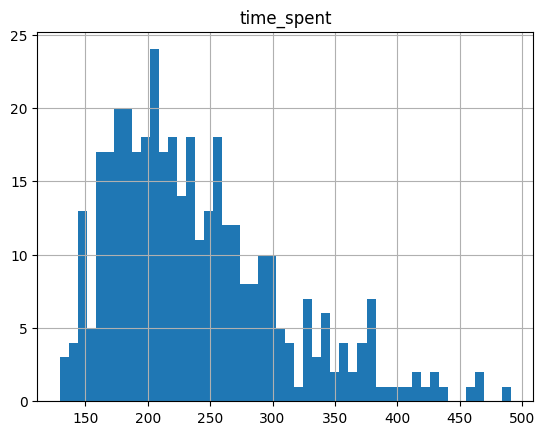

In [16]:
good_stations_stat = good_data.pivot_table(index='id', values='time_spent', aggfunc='median')
good_stations_stat.hist(bins=50)

1.4 Всё готово для составления рейтинга сетей АЗС.

Примените pivot_table к good_data и постройте рейтинг, где каждому названию сети АЗС соответствует медианное время заправки. Сводную таблицу сохраните в good_stat.

Выведите good_stat, отсортировав по возрастанию времени.

In [17]:
good_stat = good_data.pivot_table(index='name', values='time_spent',aggfunc='median')
good_stat.sort_values(by='time_spent', ascending=True)

,time_spent
name,
Белоцветник,156.0
Бальзамин,158.0
Незабудка,161.0
Колокольчик,161.0
Обриета,167.0
Функия,172.0
Гацания,179.0
Аммобиум,181.0
Бархатцы,181.5


2. Добавьте в stat столбец good_time_spent со значениями времени заправки в сети АЗС из good_stat. Распечатайте все значения stat.

In [18]:
stat = data.pivot_table(index='name', values='time_spent')

In [22]:
stat['good_time_spent'] = good_stat['time_spent']
stat.reset_index()

,name,time_spent,good_time_spent
0,Агератум,337.802721,309.5
1,Амарант,132.760012,188.0
2,Аммобиум,256.708042,181.0
3,Арктотис,73.879984,185.0
4,Астильба,376.143149,424.0
5,Бальзамин,134.508411,158.0
6,Бархатцы,145.300328,181.5
7,Бегония,163.200647,195.0
8,Белоцветник,100.818966,156.0
9,Василёк,268.849897,264.0


3. Примените pivot_table() и получите из good_data таблицу соответствия: идентификатор АЗС, название сети, число заездов.

Результат сохраните в переменной id_name. Выведите первые 5 строк этой таблицы.

In [27]:
id_name = good_data.pivot_table(index='id', values='name', aggfunc=['first','count'])
id_name.head().reset_index()

,id,first,count
,,name,name
0,00ca1b70,Вероника,131
1,0178ce70,Василёк,164
2,01abf4e9,Гацания,30
3,030a9067,Колокольчик,227
4,03740f2d,Василёк,157


4. Дайте имена колонкам датафрейма id_name. Первый столбец назовите 'name', а второй — 'count'.
Напечатайте первые 5 строк id_name.

In [29]:
id_name.columns = ['name', 'count'] 
id_name.head().reset_index()

,id,name,count
0,00ca1b70,Вероника,131
1,0178ce70,Василёк,164
2,01abf4e9,Гацания,30
3,030a9067,Колокольчик,227
4,03740f2d,Василёк,157


5.1 Объедините данные из id_name и good_stations_stat так, чтобы в итоговом датафрейме были все 3 столбца: 'name', 'count', 'time_spent'. 

Результат сохраните в таблице station_stat_full, напечатайте её первые 5 строк.

In [31]:
station_stat_full = id_name.join(good_stations_stat, on='id') 
station_stat_full.head().reset_index()

,id,name,count,time_spent
0,00ca1b70,Вероника,131,166.0
1,0178ce70,Василёк,164,234.5
2,01abf4e9,Гацания,30,181.5
3,030a9067,Колокольчик,227,136.0
4,03740f2d,Василёк,157,289.0


5.2 Нужно установить минимальную границу по числу заездов, ниже которой данные о среднем времени заправки можно считать ненадёжными (чтобы исключить их влияние на типичную продолжительность).

Постройте гистограмму значений 'count' из station_stat_full с 30 корзинами.

И ещё одну гистограмму по тем же значениям на 30 корзин, но для диапазона от 0 до 300 заездов.

Сравните полученные графики.

<Axes: >

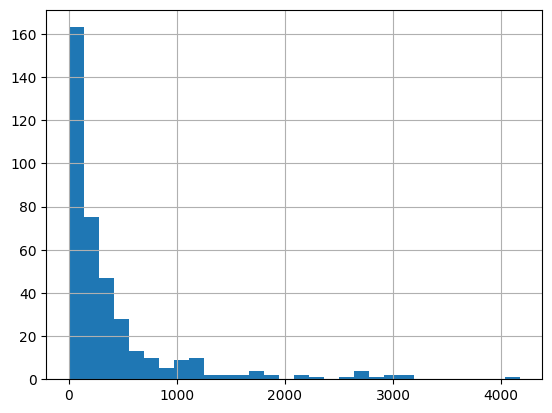

In [34]:
station_stat_full['count'].hist(bins=30)


<Axes: >

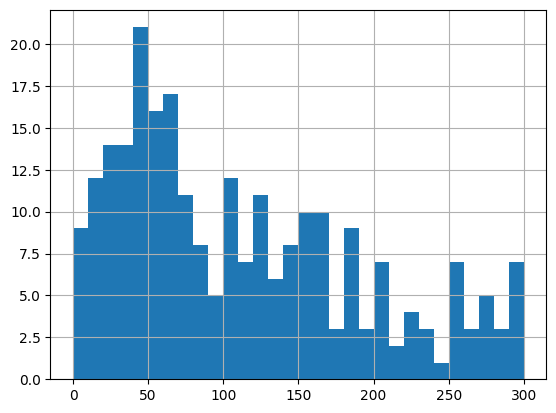

In [35]:
station_stat_full['count'].hist(bins=30, range=(0,300))

5.3 Выберите из station_stat_full АЗС с количеством заездов более 30. 

По этим данным найдите для каждой сети медиану продолжительности заправки и число АЗС. Результат сохраните в good_stat2.

Дайте столбцам с медианой и количеством станций имена 'median_time' и 'stations'. Распечатайте первые 5 строк good_stat2.

In [37]:
good_stat2 = station_stat_full.query('count > 30').pivot_table(index='name', values='time_spent', aggfunc=['median', 'count'])
good_stat2.columns = ['median_time', 'stations']
print(good_stat2.head())

          median_time  stations
name                           
Агератум       308.50         3
Амарант        169.00         5
Аммобиум       179.25         4
Арктотис       190.50         3
Астильба       440.25         4


5.4  Объедините данные таблиц stat и good_stat2, чтобы получился датафрейм со столбцами: 'time_spent', 'good_time_spent', 'median_time', 'stations'. 

Результат сохраните в датафрейме final_stat. Распечатайте его целиком и просмотрите значения в столбцах 'good_time_spent' и 'median_time'.

In [40]:
final_stat = stat.join(good_stat2)
final_stat.head().reset_index()

,name,time_spent,good_time_spent,median_time,stations
0,Агератум,337.802721,309.5,308.50,3.0
1,Амарант,132.760012,188.0,169.00,5.0
2,Аммобиум,256.708042,181.0,179.25,4.0
3,Арктотис,73.879984,185.0,190.50,3.0
4,Астильба,376.143149,424.0,440.25,4.0
